# Nouveau modèle (réunion du 11/07)

Ce notebook est centré sur le nouveau modèle proposé lors de la réunion du 11/07, avec Florence, Gabriel et Olivier

### <span style="color:red">nouveau modèle</span> suggéré par Olivier et Oana
$S(t)$ variable qui modélise l'état inflammatoire résultant de l'injection du signal immun et de l'activation des chimiokines dans les macrophages lining et les fibroblastes. 

L'état inflammatoire  $S(t)$ est renforcé par les neutrophiles N et inhibés par les  macrophages SL-TRM T.

L'inflammation fait croître davantage les neutrophiles (facteur $\alpha$), elle fait croître les momac (facteur $\beta$) et elle fait décroître les SL-TRM (facteur $\gamma$)

**On ne suit plus la population de fibroblastes, mais plutôt la population de neutrophiles qui sont appelés par les chimiokines inflammatoires.**

N(t) : population de <span style="color:red">neutrophiles</span>

M(t) : population de Momac

T(t) : population de macrophages SL-TRM

$$ \begin{aligned}
\frac{dS}{dt} &=& \color{red}{(a\, N - b\,T)} & \, S & \\
\frac{dN}{dt} &=& \alpha \, S\,N &-\delta_N\,N\cdot (N-1)& \\
\frac{dM}{dt} &=&  \beta\,\color{red} {\, S} &&-\delta_M\, M\cdot (M-1) \\
\frac{dT}{dt} &=&-\gamma S\, T & &+\delta_M\,M\cdot (1-T)
\end{aligned}
$$

```mermaid
flowchart LR
    subgraph "Modèle 4 compartiments"
        S["Signal immun inflammatoire"]
        N["Neutrophiles"]
        M["Momac (Monocytes/Macrophages)"]
        T["SL-TRM Macrophages"]
    end

    N -- "renforce (a)" --> S
    T -- "inhibe (b)" --> S
    S -- "croissance (α)" --> N
    S -- "croissance (β)" --> M
    S -- "décroissance (γ)" --> T
    N -- "destruction (δ_N)" --> N
    M -- "destruction (δ_M)" --> M
    M -- "conversion (δ_M)" --> T


![Schéma du modèle](/home/pascal/imagcloud/IMMUN4CURE/brain-storming/schema_mermaid.png)

## 1. Importer les bibliothèques nécessaires

Nous importons numpy, matplotlib.pyplot, scipy.integrate.solve_ivp, et ipywidgets pour les simulations et l'interactivité.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
import ipywidgets as widgets
from ipywidgets import interact, fixed

## 2. Définir le système différentiel du nouveau modèle

La fonction `system_adim_oliv` implémente les équations différentielles du modèle adimensionné avec neutrophiles, Momac, SL-TRM et signal inflammatoire, selon la proposition d'Olivier et Oana.

In [2]:
def system_adim_oliv(t, y, alpha, beta, gamma, delta_N, delta_M, a, b):
    """
    y : vecteur (S N M T) 
    S : signal inflammatoire adimensionné
    N : Neutrophiles adimensionnés
    M : Monocytes Macrophages  adimensionnés
    T : SL-TRM Macrophages adimensionnés

    la valeur d'équilibre physiologique des neutrophiles est 1
    la valeur d'équilibre physiologique des Momac est 1
    la valeur d'équilibre physiologique des SL-TRM est 1
    alpha <1 est le taux de croissance des neutrophiles causé par l'inflammation
    beta  est le taux de croissance des Momac causé par l'inflammation
    gamma est le taux de destruction des SL-TRM causé par l'inflammation 
    delta_N est le taux de destruction des neutrophiles
    delta_M est le taux de conversion  Momac -> SL-TRM  
    """

    S, N, M, T = y

    dSdt =  (a* N - b* T)*S
    dNdt = alpha * S*N - delta_N * N * (N-1)
    dMdt = beta *S - delta_M * M*(M-1)
    dTdt = -gamma * S * T + delta_M *M *(1-T)

    return [dSdt, dNdt, dMdt, dTdt]

## 3. Définir la fonction de simulation

La fonction `inflam_adim_oliv` résout le système différentiel et trace les résultats pour visualiser l'évolution des différentes populations et du signal inflammatoire.

In [3]:
def inflam_adim_oliv(y0, alpha, beta, gamma, delta_N, delta_M, a, b, duree):

    # Résolution des équations différentielles du modèle de la réponse immunitaire
    # le système est raide, on utilise la méthode BDF
    sol = solve_ivp(system_adim_oliv, [0, duree], y0, 'Radau',t_eval=np.arange(0,duree,duree/100), dense_output=False,
                    args=(alpha, beta, gamma, delta_N, delta_M, a, b))
    S,N,M,T = sol.y
    t=sol.t
    # Traçage des résultats
    plt.figure(figsize=(12, 8))

    plt.subplot(321)
    plt.plot(t, S, 'b', label='inflammation')
    plt.ylabel('inflammation')
    plt.title('signal inflammatoire')

    plt.subplot(322)
    plt.plot(t, N, 'r', label='Neutrophiles')
    plt.ylabel('Neutrophiles')
    plt.ticklabel_format(style='plain', axis='y')
    plt.ylim(bottom=0)
    plt.title('neutrophiles')

    plt.subplot(323)
    plt.plot(t,M, 'g')
    plt.xlabel('temps ')
    plt.ylabel('Monocytes Macrophages')
    plt.ticklabel_format(style='plain', axis='y')
    plt.ylim(bottom=0)
    plt.title('monocytes macrophages')

    plt.subplot(324)
    plt.plot(t,T, 'm')
    plt.xlabel('temps ')
    plt.ylabel('SL-TRM Macrophages')
    plt.ticklabel_format(style='plain', axis='y')
    plt.ylim(bottom=0)
    plt.title('macrophages SL-TRM')

    plt.subplot(325)
    plt.plot(M,T, 'm')
    plt.xlabel('Momac')
    plt.ylabel('SL-TRM Macrophages')
    plt.ticklabel_format(style='plain', axis='y')
    plt.ylim(bottom=0)
    plt.figtext(0.3, 0.01, 'Plan de phase entre Momac et SL-TRM ', ha='center', fontsize=12)

    plt.subplot(326)
    plt.plot(S,T, 'm')
    plt.xlabel('signal inflammatoire')
    plt.ylabel('SL-TRM Macrophages')
    plt.ticklabel_format(style='plain', axis='y')
    plt.ylim(bottom=0)
    plt.figtext(0.7, 0.01, 'Plan de phase entre inflammation et SL-TRM ', ha='center', fontsize=12)

    print('valeurs finales:',f"Signal={S[-1]:.3f}, Neutrophiles={N[-1]:.3f}, Momac={M[-1]:.3f}, SL-TRM={T[-1]:.3f}")
    plt.show()
    return

## 4. Exécuter une simulation de base avec inflam_adim_oliv

On observe le comportement du modèle avec des paramètres standards.

valeurs finales: Signal=0.000, Neutrophiles=1.000, Momac=1.000, SL-TRM=1.000


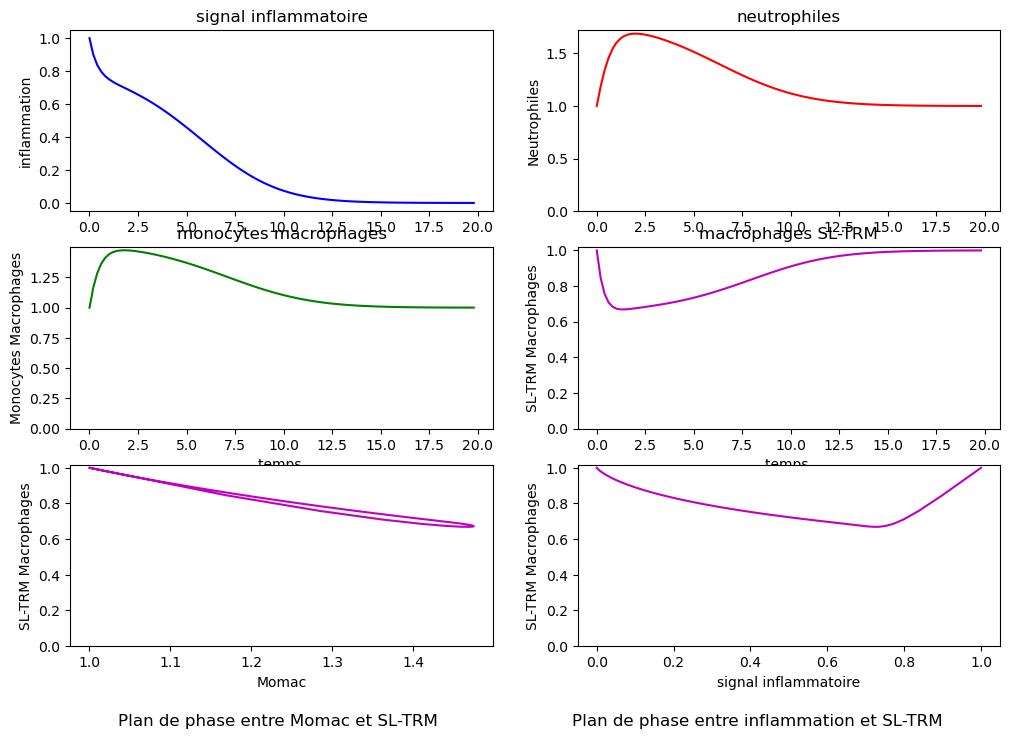

In [4]:
inflam_adim_oliv([1, 1, 1, 1],
       alpha=1, beta=1, gamma=1,
       delta_N=1, delta_M=1,a=0.35, b=1, duree=20)

## 5. Tester la stabilité de l’équilibre physiologique

Exemple où l’équilibre physiologique est stable (par exemple, a + b > seuil).

valeurs finales: Signal=0.001, Neutrophiles=1.001, Momac=1.001, SL-TRM=0.999


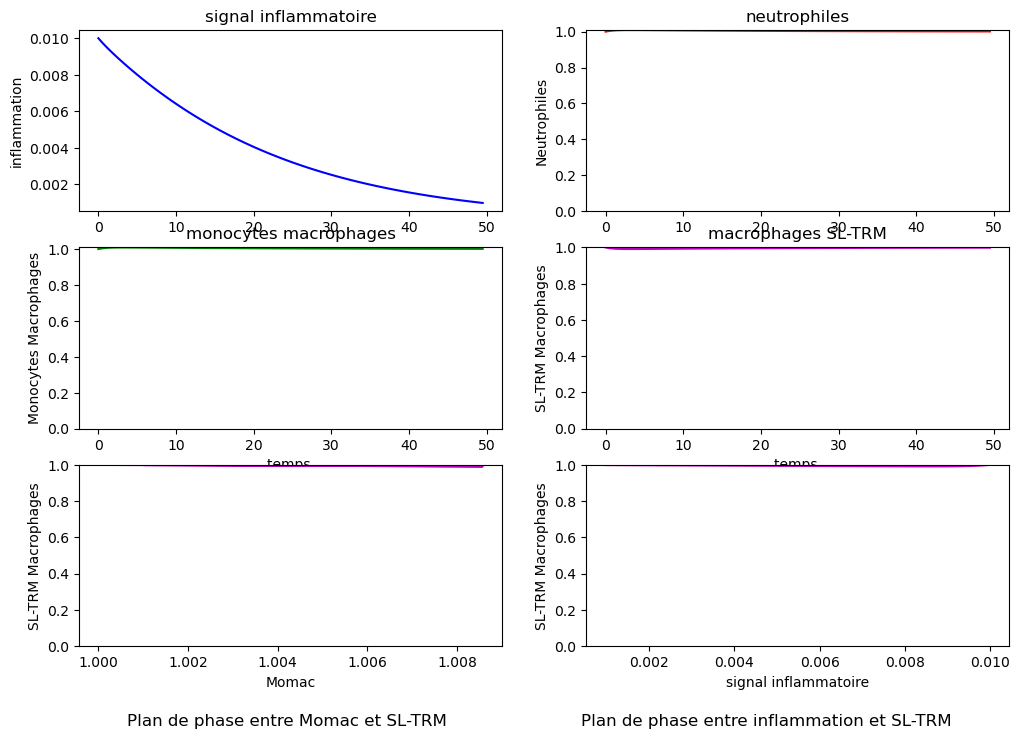

In [5]:
#l'équilibre physiologique est stable si a + b > seuil
inflam_adim_oliv([0.01, 1, 1, 1],
       alpha=1, beta=1, gamma=1,
       delta_N=1, delta_M=1,a=0.35, b=0.40, duree=50)

## 6. Tester l’instabilité de l’équilibre physiologique

Exemple où l’équilibre physiologique est instable (par exemple, a + b < seuil).

valeurs finales: Signal=0.453, Neutrophiles=1.398, Momac=1.309, SL-TRM=0.760


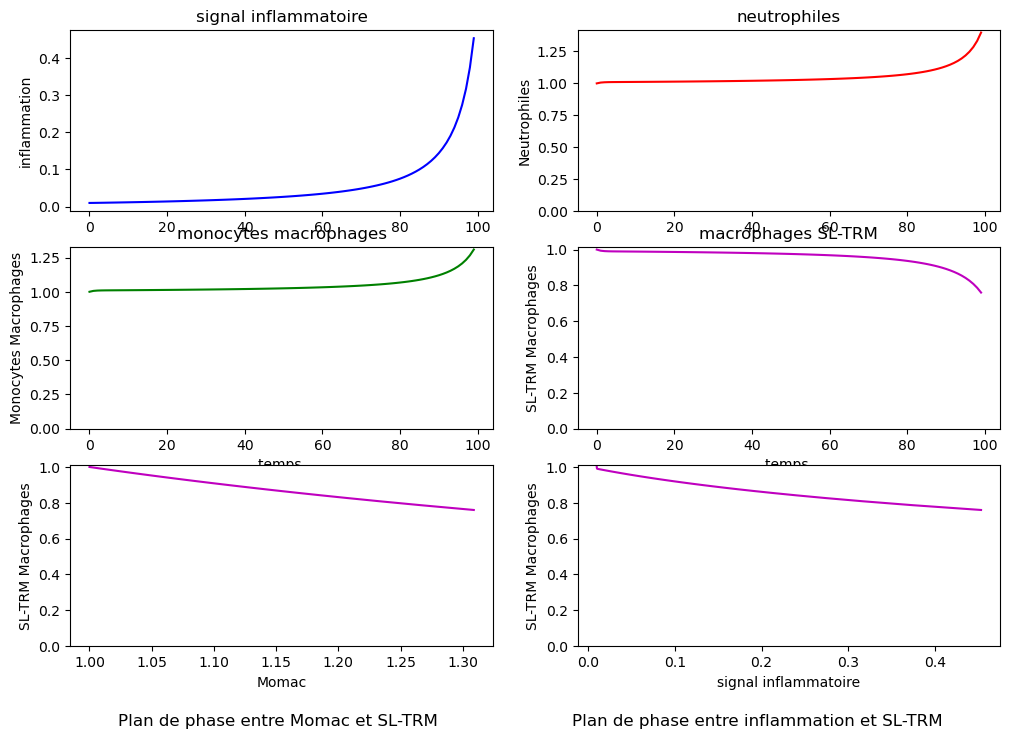

In [6]:
#l'équilibre physiologique est instable si a + b < seuil
inflam_adim_oliv([0.01, 1, 1, 1],
       alpha=1, beta=1, gamma=1,
       delta_N=1, delta_M=1,a=0.31, b=0.30, duree=100)

## 7. Créer une interface interactive pour explorer le modèle

Utilisez les curseurs pour explorer dynamiquement l'effet des paramètres sur le modèle.

In [7]:
# Définition de la fonction interactive
def interactive_inflam_oliv(alpha,beta,gamma,delta_N,delta_M, a, b, duree):
    inflam_adim_oliv([1, 1.00, 1, 1],
           alpha, beta, gamma, delta_N, delta_M, a, b, duree)

# Création des curseurs pour les paramètres
ui = widgets.HBox([
    widgets.VBox([
        widgets.FloatSlider(min=0, max=100, step=0.1, value=1, description='alpha neutrophiles <-signal'),
        widgets.FloatSlider(min=0, max=100, step=0.1, value=1, description='beta Momac <- neutrophiles'),
        widgets.FloatSlider(min=0, max=100, step=0.1, value=1, description='gamma  SL-TRM <- signal'),
        widgets.FloatSlider(min=0, max=100, step=0.1, value=1, description='delta_N  neutrophiles'),
    ]),
    widgets.VBox([
        widgets.FloatSlider(min=0, max=100, step=0.1, value=1, description='delta_M conversion  Momac -> SL-TRM'),
        widgets.FloatSlider(min=0, max=1, step=0.01, value=0.35, description='a feed-back neutrophiles -> signal'),
        widgets.FloatSlider(min=0, max=1, step=0.01, value=1, description='b hold-back SL-TRM -> signal'),
        widgets.IntSlider(min=0, max=20, step=1, value=10, description='durée de la simulation'),
    ])
])

out = widgets.interactive_output(
    interactive_inflam_oliv,
    {
        'alpha': ui.children[0].children[0],
        'beta': ui.children[0].children[1],
        'gamma': ui.children[0].children[2],
        'delta_N': ui.children[0].children[3],
        'delta_M': ui.children[1].children[0],
        'a': ui.children[1].children[1],
        'b': ui.children[1].children[2],
        'duree': ui.children[1].children[3],
    }
)

display(ui, out)

Output()

Il faut étudier avec précision les équilibres et les conditions de stabilité du système.

interface graphique pour trouver les points d'équilibre non triviaux, intersection de la parabole
$$
N^* = 1 + \frac{\alpha \delta_M}{\beta \delta_N} M^* (M^* - 1)
$$
et de l'hyperbole
$$
M^* =  \frac{a \,\gamma \,\delta_N}{b\, \alpha \,\delta_M} \frac{N^* (N^* - 1)}{(1 - \frac{a}{b} N^*)}
=-\frac{\gamma \delta_N}{\alpha \delta_M}  (N^* + b/a -1) + \frac{(b/a)^{2}(1-b/a)}{(N^* - b/a)} 

$$


In [13]:
import numpy as np
import ipywidgets as widgets
from ipywidgets import interact

import matplotlib.pyplot as plt

def plot_equilibres(a_b=1.0, alpha_beta=1.0, gamma_alpha=1.0, deltaN_deltaM=1.0):
    # N* range, avoid division by zero
    N = np.linspace(-10, 10, 2000)
    M = np.linspace(-10, 20, 2000)
    
    N_parabole= 1 + (alpha_beta/deltaN_deltaM)*(M - 1)*M
    #M_hyperbole = (a_b*gamma_alpha * deltaN_deltaM * N * (N - 1)) / (1 - a_b*N)

    # Avoid division by zero for N/a_b and N_star/a_b
    # Hyperbole : séparer les deux branches
    N_safe_left = N[N < 1/a_b - 1e-6]
    N_safe_right = N[N > 1/a_b + 1e-6]
    #M_hyperbole_left = (a_b*gamma_alpha * deltaN_deltaM * N_safe_left * (N_safe_left - 1)) / (1 - N_safe_left*a_b)
    #M_hyperbole_right = (a_b*gamma_alpha * deltaN_deltaM * N_safe_right * (N_safe_right - 1)) / (1 - N_safe_right*a_b)
    M_hyperbole_left = -gamma_alpha*deltaN_deltaM*(N_safe_left + 1/a_b -1)+ (1/a_b)**2 *(1- 1/a_b)/(N_safe_left - 1/a_b)
    M_hyperbole_right = -gamma_alpha*deltaN_deltaM*(N_safe_right + 1/a_b -1)+ (1/a_b)**2 *(1- 1/a_b)/(N_safe_right - 1/a_b)
    # tracé
    plt.figure(figsize=(8,6))
    plt.plot(N_parabole, M, label="nullcline N", color='blue')
    plt.plot(N_safe_left, M_hyperbole_left, label="", color='red')
    plt.plot(N_safe_right, M_hyperbole_right, label="nullcline M ", color='red')
    plt.plot(N, (-gamma_alpha * deltaN_deltaM * (N + 1/a_b -1) ), label="oblique asymptote", color='k', linestyle=':', linewidth=1)
    plt.plot((1/a_b)*np.ones_like(M), M, 'k:', label=" vertical asymptote N=b/a")
    plt.xlabel('$N^*$')
    plt.ylabel('$M^*$')
    plt.title(f"Equilibria points\n a/b={a_b:.2f}, α/β={alpha_beta:.2f}, γ/α={gamma_alpha:.2f}, δN/δM={deltaN_deltaM:.2f}")
    plt.ylim(-10, 10)
    plt.xlim(-10, 20)
    plt.legend()
    plt.grid(True)
    #plt.show()

interact(
    plot_equilibres,
    a_b=widgets.FloatSlider(min=0.1, max=10.0, step=0.01, value=1.0, description='a/b'),
    alpha_beta=widgets.FloatSlider(min=0.1, max=10.0, step=0.01, value=1.0, description='α/β'),
    gamma_alpha=widgets.FloatSlider(min=0.1, max=100, step=0.01, value=1.0, description='γ/α'),
    deltaN_deltaM=widgets.FloatSlider(min=0.1, max=10.0, step=0.01, value=1.0, description='δN/δM')
)


interactive(children=(FloatSlider(value=1.0, description='a/b', max=10.0, min=0.1, step=0.01), FloatSlider(val…

<function __main__.plot_equilibres(a_b=1.0, alpha_beta=1.0, gamma_alpha=1.0, deltaN_deltaM=1.0)>

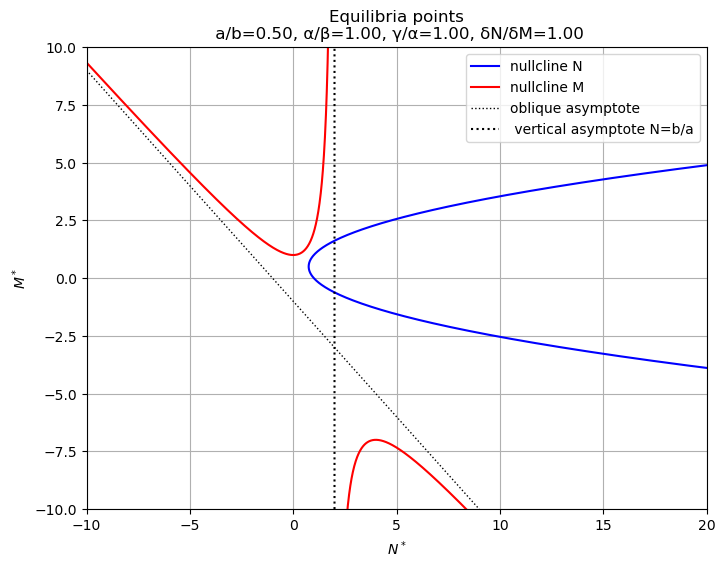

In [14]:
plot_equilibres(a_b=0.5, alpha_beta=1, gamma_alpha=1, deltaN_deltaM=1)
plt.savefig('equilibres.png', format = 'png')

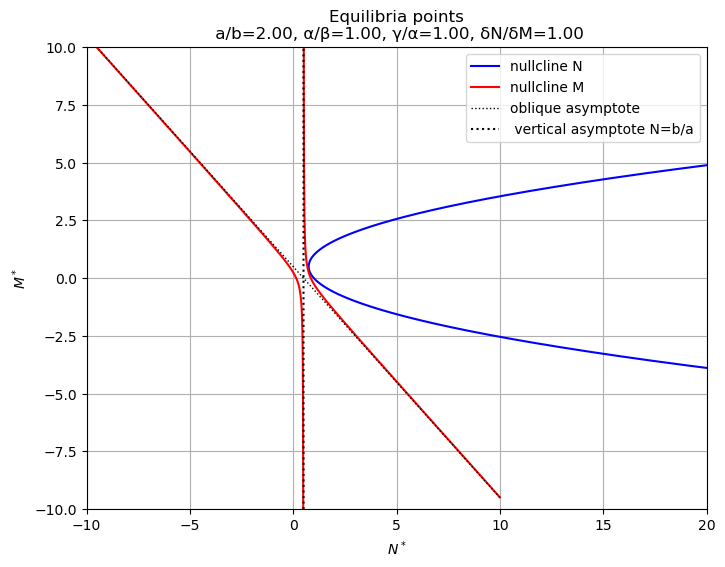

In [15]:
plot_equilibres(a_b=2, alpha_beta=1, gamma_alpha=1, deltaN_deltaM=1 )
plt.savefig('equilibres_1.png', format = 'png')


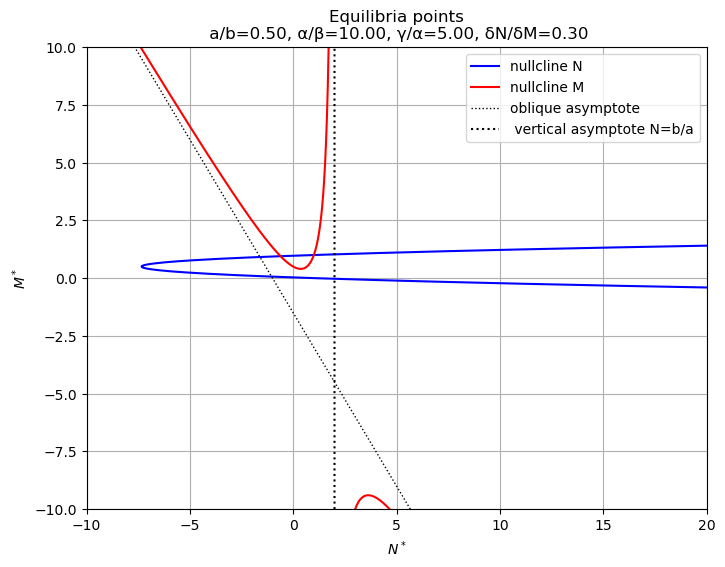

In [16]:
plot_equilibres(a_b=0.5, alpha_beta=10, gamma_alpha=5, deltaN_deltaM=0.3 )
plt.savefig('equilibres_2.png', format = 'png')

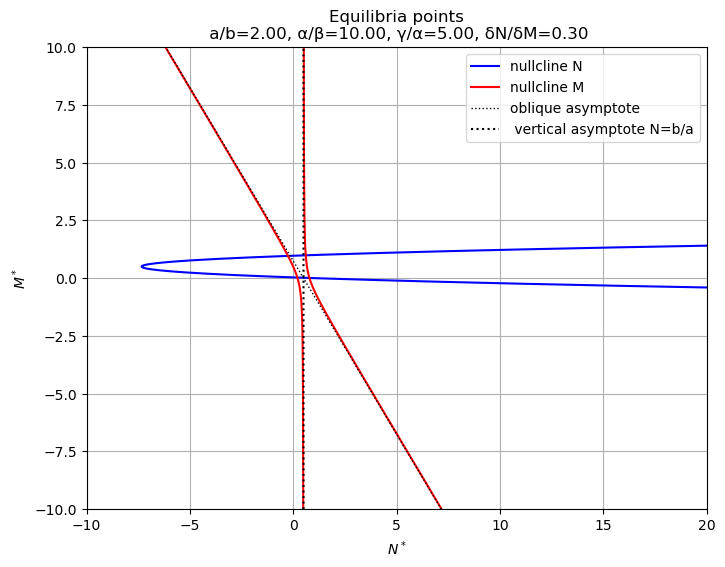

In [12]:
plot_equilibres(a_b=2, alpha_beta=10, gamma_alpha=5, deltaN_deltaM=0.3 )
plt.savefig('equilibres_3.png', format = 'png')